In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [3]:
with open('data_simple_line_perturbed_2D_1000_turns.pkl', 'rb') as f:
    data = pickle.load(f)

In [4]:
data.keys()

dict_keys(['x', 'px'])

In [5]:
data['x'].shape, data['px'].shape

((1600, 1001), (1600, 1001))

Text(0, 0.5, '$p_x$')

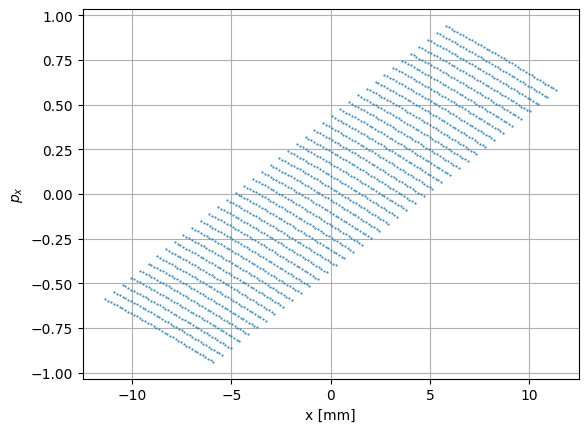

In [6]:
plt.plot(data['x'][:, 100] * 1000, data['px'][:, 1000] * 100, '.', markersize=1, color='C0')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

In [7]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from models import GSympNet

In [8]:
# Hyperparameters
dim = 2
layers = 3
width = 20
activation = torch.sigmoid
epochs = 10000
batch_size = 64
learning_rate = 1e-3

In [9]:
# # x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(data['x'].shape[0])]
# x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(700)]
# x_xp_data = np.vstack(x_xp_data_list)

In [10]:
def min_max_normalize(arr, min_val=None, max_val=None):
    """
    Min-max normalize a numpy array or torch tensor of shape (N, 2) to range [-1, 1].
    If min_val and max_val are not provided, compute from arr along axis=0.
    Returns normalized array, min_val, and max_val.
    """
    if min_val is None:
        min_val = arr.min(axis=0, keepdims=True)
    if max_val is None:
        max_val = arr.max(axis=0, keepdims=True)
    normalized = 2 * (arr - min_val) / (max_val - min_val) - 1
    return normalized, min_val, max_val

def min_max_denormalize(arr, min_val, max_val):
    """
    Denormalize a numpy array or torch tensor of shape (N, 2) from range [-1, 1]
    back to the original range defined by min_val and max_val.
    """
    return (arr + 1) / 2 * (max_val - min_val) + min_val

In [11]:
index = 0
x_xp_data = np.array([data['x'][index, :700], data['px'][index, :700]]).T

In [12]:
x_xp_data.shape, x_xp_data.dtype

((700, 2), dtype('float64'))

In [13]:
x_xp_data_norm, min, max = min_max_normalize(x_xp_data)

In [14]:
input, output = x_xp_data_norm[:-1], x_xp_data_norm[1:]

In [15]:
input-output

array([[-0.87911808, -1.49374875],
       [-0.61498224,  1.7629765 ],
       [ 1.68373775, -0.83115193],
       ...,
       [ 1.32292196,  1.12792126],
       [ 0.089854  , -1.82364246],
       [-1.43886238,  1.2665704 ]], shape=(699, 2))

In [16]:
train_x = torch.tensor(input, dtype=torch.float32)
train_y = torch.tensor(output, dtype=torch.float32)

In [17]:
train_x.shape

torch.Size([699, 2])

In [18]:
dataset = TensorDataset(train_x, train_y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [19]:
model = GSympNet(dim, layers, width, activation)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

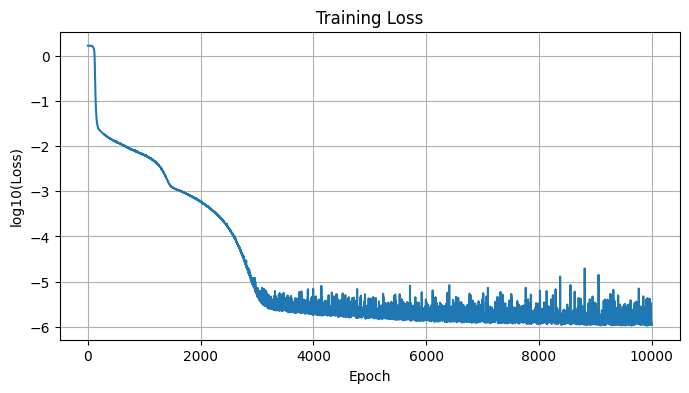

In [23]:
losses = []

model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(dataset)
    losses.append(avg_loss)
    # print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.10f}")
    
    # Real-time plot
    if (epoch+1) % 10 == 0 or epoch == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8,4))
        # plt.plot(losses)
        # plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.plot(np.log10(losses))
        plt.ylabel('log10(Loss)')
        plt.title('Training Loss')
        plt.grid()
        plt.show()

In [24]:
torch.save(model.state_dict(),'sympnet_model_particle11.pt')

In [21]:
# Re-instantiate the model and load the saved weights
model = GSympNet(dim, layers, width, activation)
model.load_state_dict(torch.load('sympnet_model_particle11.pt'))

<All keys matched successfully>

In [22]:
x_xp_init_test = np.array([data['x'][index, 700], data['px'][index, 700]]).T

In [23]:
x_xp_init_test = x_xp_init_test.reshape(1, 2)
x_xp_init_test.shape, x_xp_init_test.dtype

((1, 2), dtype('float64'))

In [24]:
min.dtype

dtype('float64')

In [25]:
x_xp_init_test_norm = min_max_normalize(x_xp_init_test, min, max)[0]

In [26]:
x_xp_init_test_tensor = torch.tensor(x_xp_init_test_norm, dtype=torch.float32)

In [27]:
# x_xp_init_test_tensor = x_xp_init_test_tensor.unsqueeze(0)  # Add batch dimension
x_xp_init_test_tensor.shape

torch.Size([1, 2])

In [28]:
pred_init = model.predict(x_xp_init_test_tensor, steps=301)

In [29]:
x_xp_test = np.array([data['x'][index, 701:], data['px'][index, 701:]]).T

In [30]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

Text(0, 0.5, '$p_x$')

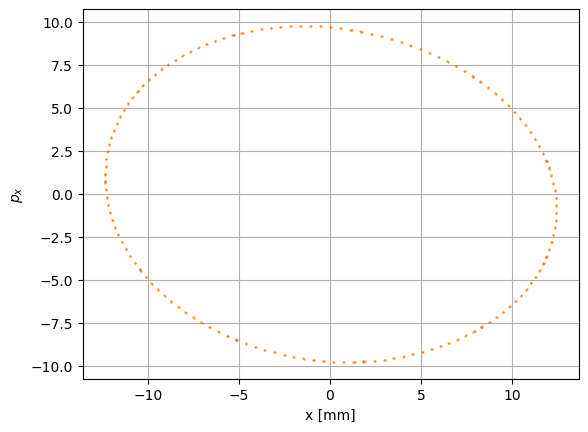

In [34]:
plt.plot(x_xp_test[1:11, 0] * 1000, x_xp_test[1:11, 1] * 1000, '.', markersize=1, color='C0')
plt.plot(pred[:10, :, 0] * 1000, pred[:10, :, 1] * 1000, '.', markersize=1, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

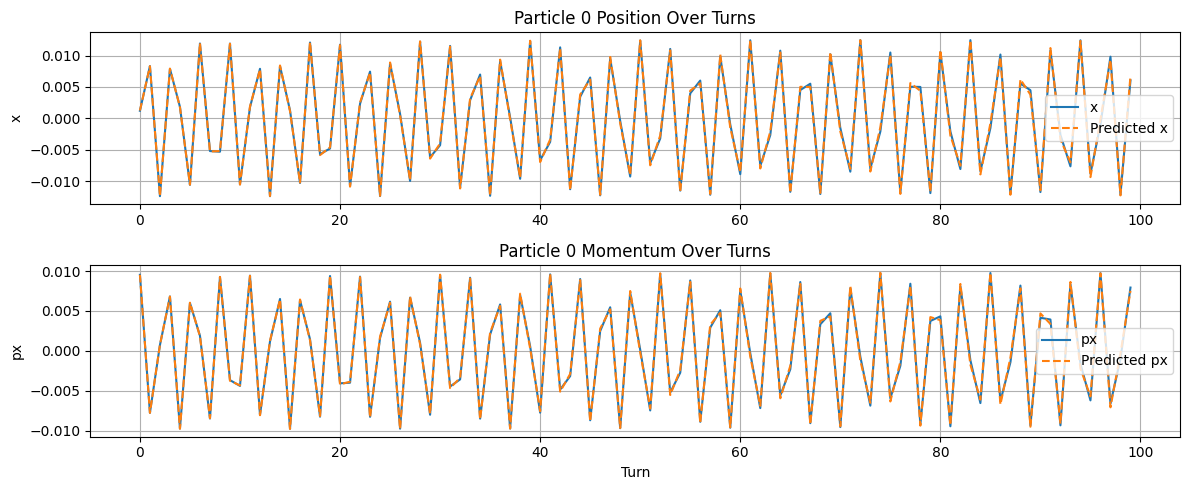

In [37]:
# Plot position and momentum over turns
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(x_xp_test[:100, 0], label='x', color='C0')
plt.plot(pred[:, :100, 0].squeeze(), label='Predicted x', linestyle='--', color='C1')
plt.title(f'Particle {index} Position Over Turns')
plt.ylabel('x')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(x_xp_test[:100, 1], label='px', color='C0')
plt.plot(pred[:, :100, 1].squeeze(), label='Predicted px', linestyle='--', color='C1')
plt.title(f'Particle {index} Momentum Over Turns')
plt.xlabel('Turn')
plt.ylabel('px')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()